# MCMC Kernels on Challenging 2D Densities

We compare MCMC kernels on three targets:
1. **Neal's funnel** — varying curvature, strong correlation
2. **Gaussian mixture** — 5 well-separated modes, discrete multimodality
3. **Rosenbrock (banana)** — thin curved ridge, highly correlated

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_platform_name", "cpu")

from probjax.inference.mcmc import (
    hmc,
    nuts,
    dynamic_hmc,
    mala,
    gauss_rwmh,
    gaussian_imh,
    elliptical_slice,
    slice,
    latent_slice,
    mclmc,
    adjusted_mclmc,
    adjusted_mclmc_dynamic,
)
from probjax.inference.mcmc_runner import MCMC

## Target densities

In [2]:
# --- Neal's funnel ---
def funnel_logdensity(z):
    x, v = z[0], z[1]
    return jax.scipy.stats.norm.logpdf(v, 0.0, 3.0) + \
           jax.scipy.stats.norm.logpdf(x, 0.0, jnp.exp(v / 2.0))

key = jax.random.PRNGKey(42)
v_ref = jax.random.normal(key, (100_000,)) * 3.0
key, subkey = jax.random.split(key)
x_ref = jax.random.normal(subkey, (100_000,)) * jnp.exp(v_ref / 2.0)


# --- Gaussian mixture ---
mixture_means = jnp.array([
    [10.0, 0.0], [0.0, 10.0], [-10.0, 0.0], [0.0, -10.0], [0.0, 0.0],
])
mixture_std = 0.7

def mixture_logdensity(z):
    logps = jax.vmap(
        lambda mu: jax.scipy.stats.norm.logpdf(z, mu, mixture_std).sum()
    )(mixture_means)
    return jax.scipy.special.logsumexp(logps) - jnp.log(len(mixture_means))

key = jax.random.PRNGKey(99)
comp = jax.random.choice(key, len(mixture_means), shape=(100_000,))
key, subkey = jax.random.split(key)
y_ref = mixture_means[comp] + jax.random.normal(subkey, (100_000, 2)) * mixture_std


# --- Rosenbrock (banana) ---
def rosenbrock_logdensity(z):
    x, y = z[0], z[1]
    return -(1.0 - x) ** 2 - 10.0 * (y - x ** 2) ** 2

key = jax.random.PRNGKey(7)
# Sample via rejection sampling around the ridge
proposal_mean = jnp.array([1.0, 1.0])
proposal_std = jnp.array([1.0, 5.0])
candidates = jax.random.normal(key, (1_000_000, 2)) * proposal_std + proposal_mean
key, subkey = jax.random.split(key)
log_u = jax.random.uniform(subkey, (1_000_000,)) * 20.0 - 20.0
log_p = jax.vmap(rosenbrock_logdensity)(candidates)
log_g = jax.vmap(lambda z: jax.scipy.stats.norm.logpdf(z[0], 1.0, 1.0)
                          + jax.scipy.stats.norm.logpdf(z[1], 1.0, 5.0))(candidates)
mask = log_u < log_p - log_g
print(mask.sum())
b_ref = candidates[mask][:100_000]

W0508 20:32:19.122958 21461657 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


160018


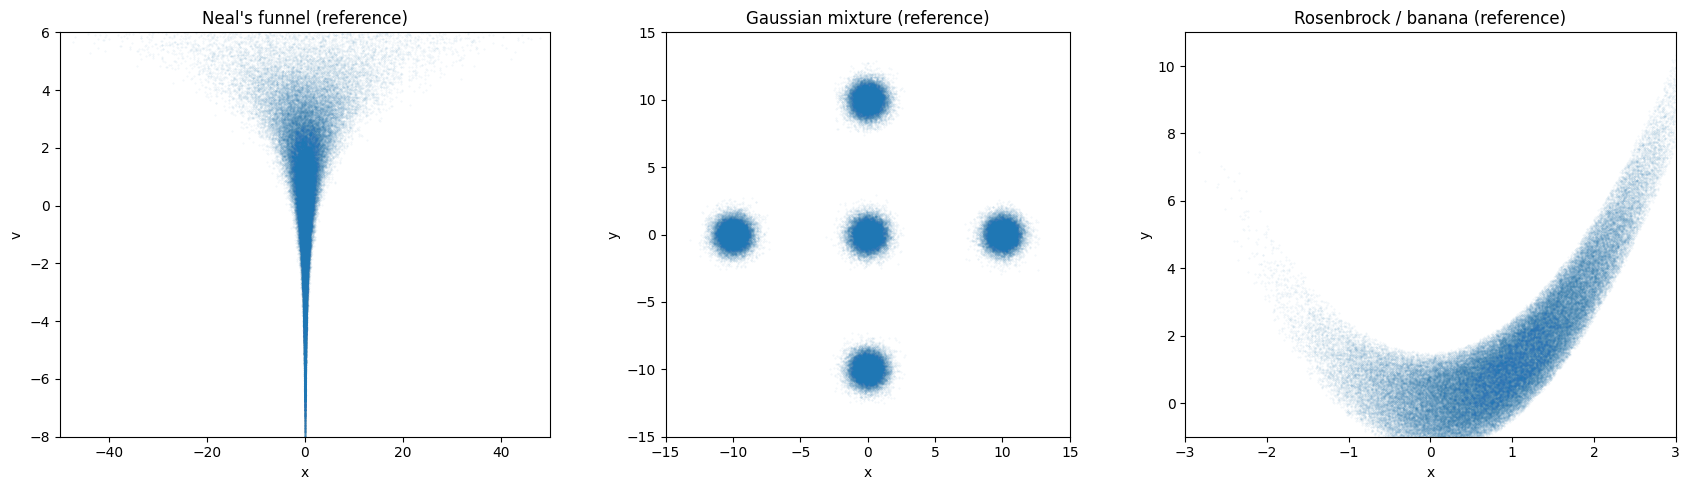

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(x_ref, v_ref, s=0.1, alpha=0.1, rasterized=True)
axes[0].set_xlim(-50, 50); axes[0].set_ylim(-8, 6)
axes[0].set_xlabel("x"); axes[0].set_ylabel("v")
axes[0].set_title("Neal's funnel (reference)")

axes[1].scatter(y_ref[:, 0], y_ref[:, 1], s=0.1, alpha=0.1, rasterized=True)
axes[1].set_xlim(-15, 15); axes[1].set_ylim(-15, 15)
axes[1].set_aspect("equal")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Gaussian mixture (reference)")

axes[2].scatter(b_ref[:, 0], b_ref[:, 1], s=0.1, alpha=0.1, rasterized=True)
axes[2].set_xlim(-3, 3); axes[2].set_ylim(-1, 11)
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
axes[2].set_title("Rosenbrock / banana (reference)")

plt.tight_layout()
plt.show()

## Helper

In [4]:
def run_mcmc(kernel, init_z, key, num_samples=20_000, thin=10, init_kwargs=None, init_params_kwargs=None):
    state = kernel.init(init_z, rng_key=key, **(init_kwargs or {}))
    params = kernel.init_params(state, **(init_params_kwargs or {}))
    samples, _ = MCMC(kernel).sample(key, state, num_samples, params=params, thin=thin)
    return samples


def plot_triplet(name, s_funnel, s_mixture, s_rosenbrock):
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    axes[0].scatter(s_funnel[:, 0], s_funnel[:, 1], s=0.5, alpha=0.4, rasterized=True)
    axes[0].set_xlim(-50, 50); axes[0].set_ylim(-8, 6)
    axes[0].set_xlabel("x"); axes[0].set_ylabel("v")
    axes[0].set_title(f"{name} — funnel")

    axes[1].scatter(s_mixture[:, 0], s_mixture[:, 1], s=0.5, alpha=0.4, rasterized=True)
    axes[1].set_xlim(-15, 15); axes[1].set_ylim(-15, 15)
    axes[1].set_aspect("equal")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
    axes[1].set_title(f"{name} — mixture")

    axes[2].scatter(s_rosenbrock[:, 0], s_rosenbrock[:, 1], s=0.5, alpha=0.4, rasterized=True)
    axes[2].set_xlim(-3, 3); axes[2].set_ylim(-1, 11)
    axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
    axes[2].set_title(f"{name} — Rosenbrock")

    plt.tight_layout()
    plt.show()

In [5]:
init_funnel = jnp.array([0.0, -1.0])
init_mixture = jnp.array([10.0, 0.0])
init_rosenbrock = jnp.array([1.0, 1.0])
key = jax.random.PRNGKey(0)

## HMC

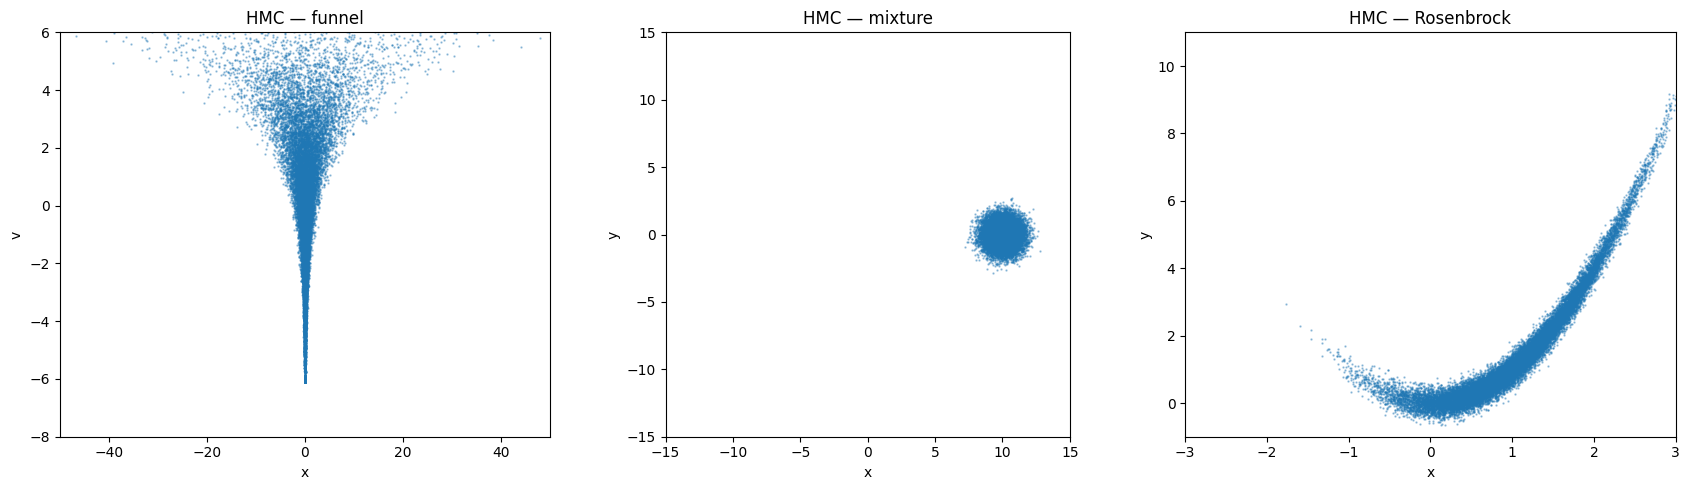

In [6]:
s_f = run_mcmc(hmc(funnel_logdensity, num_integration_steps=50), init_funnel, key, init_params_kwargs={"step_size": 0.05})
s_m = run_mcmc(hmc(mixture_logdensity, num_integration_steps=50), init_mixture, key, init_params_kwargs={"step_size": 0.05})
s_b = run_mcmc(hmc(rosenbrock_logdensity, num_integration_steps=50), init_rosenbrock, key, init_params_kwargs={"step_size": 0.05})
plot_triplet("HMC", s_f, s_m, s_b)

## NUTS

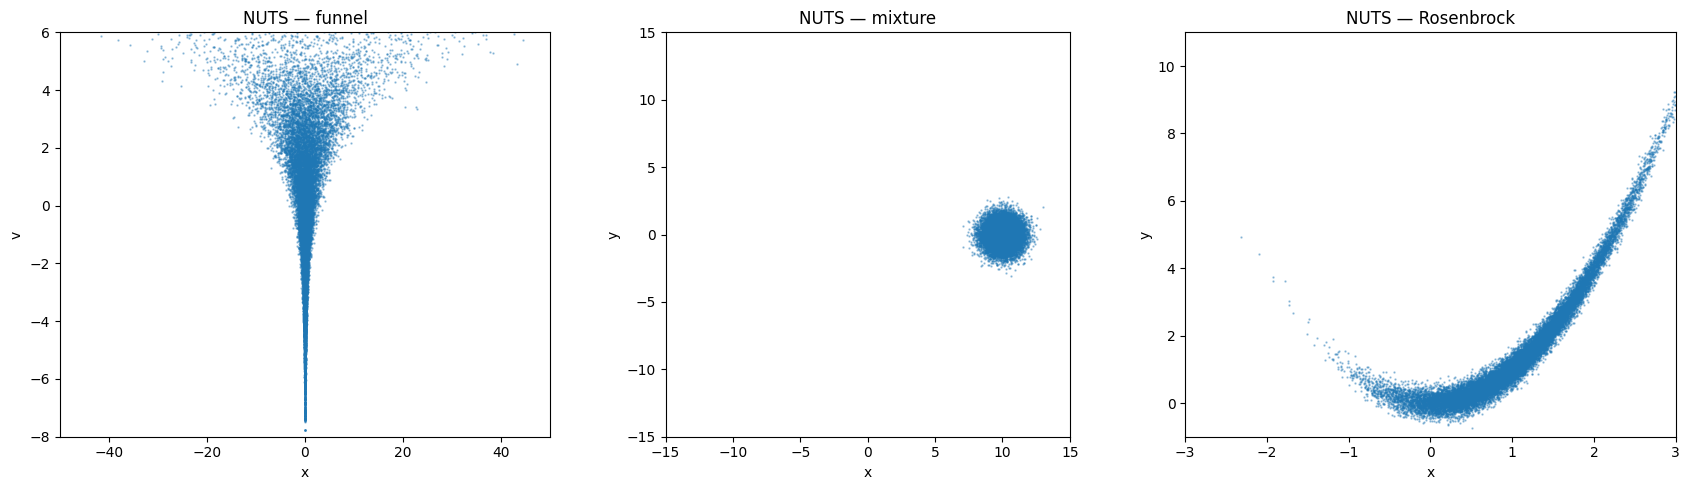

In [7]:
s_f = run_mcmc(nuts(funnel_logdensity, max_num_doublings=10), init_funnel, key, init_params_kwargs={"step_size": 0.05})
s_m = run_mcmc(nuts(mixture_logdensity, max_num_doublings=10), init_mixture, key, init_params_kwargs={"step_size": 0.05})
s_b = run_mcmc(nuts(rosenbrock_logdensity, max_num_doublings=10), init_rosenbrock, key, init_params_kwargs={"step_size": 0.05})
plot_triplet("NUTS", s_f, s_m, s_b)

## Dynamic HMC

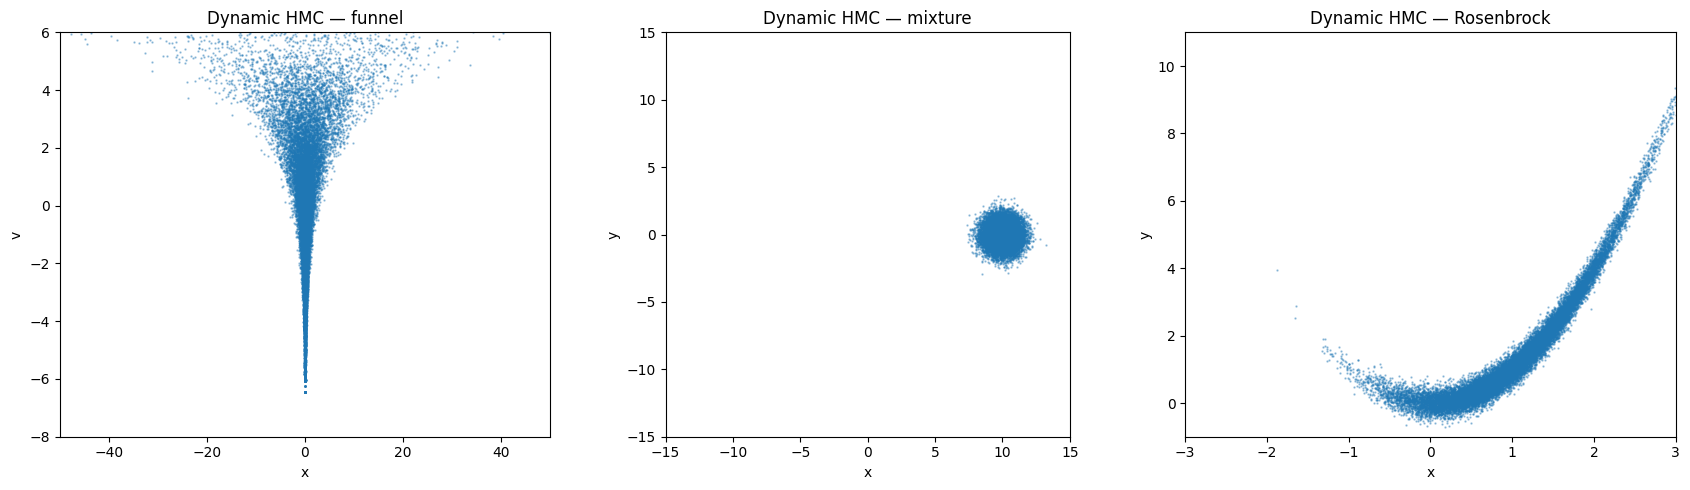

In [8]:
s_f = run_mcmc(dynamic_hmc(funnel_logdensity, average_integration_steps=50), init_funnel, key, init_params_kwargs={"step_size": 0.05})
s_m = run_mcmc(dynamic_hmc(mixture_logdensity, average_integration_steps=50), init_mixture, key, init_params_kwargs={"step_size": 0.05})
s_b = run_mcmc(dynamic_hmc(rosenbrock_logdensity, average_integration_steps=50), init_rosenbrock, key, init_params_kwargs={"step_size": 0.05})
plot_triplet("Dynamic HMC", s_f, s_m, s_b)

## MALA

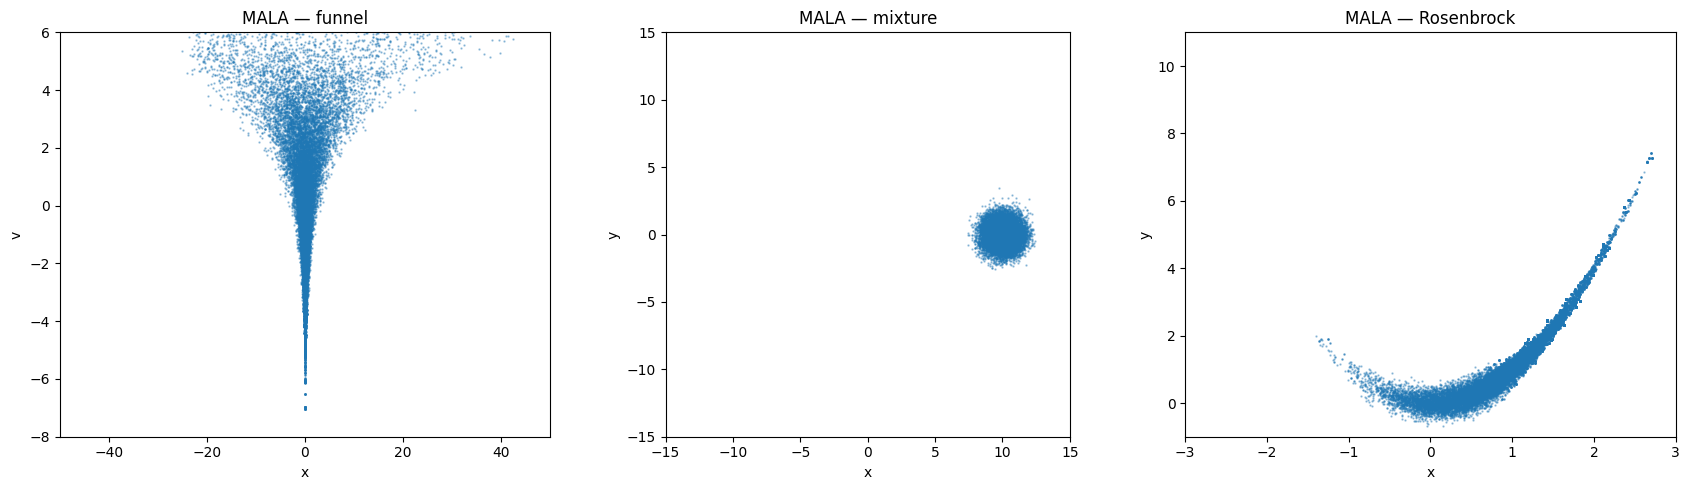

In [9]:
s_f = run_mcmc(mala(funnel_logdensity), init_funnel, key, init_params_kwargs={"step_size": 0.05})
s_m = run_mcmc(mala(mixture_logdensity), init_mixture, key, init_params_kwargs={"step_size": 0.05})
s_b = run_mcmc(mala(rosenbrock_logdensity), init_rosenbrock, key, init_params_kwargs={"step_size": 0.05})
plot_triplet("MALA", s_f, s_m, s_b)

## RW-MH

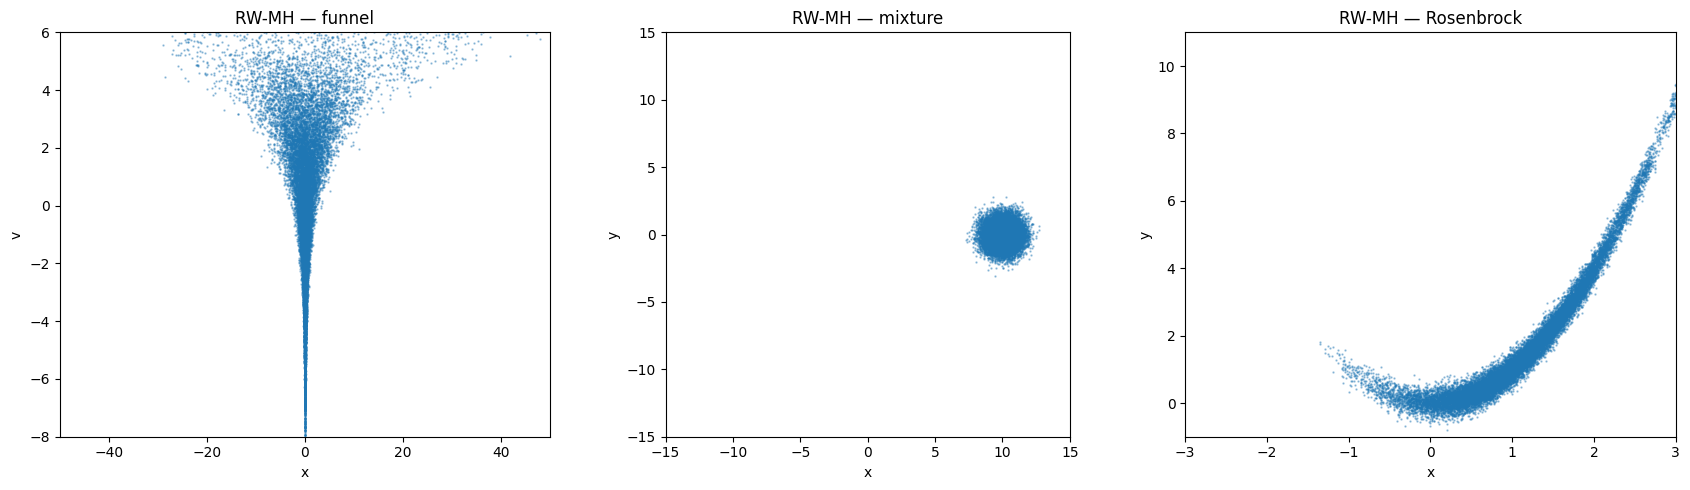

In [10]:
s_f = run_mcmc(gauss_rwmh(funnel_logdensity), init_funnel, key, init_params_kwargs={"step_size": 0.5})
s_m = run_mcmc(gauss_rwmh(mixture_logdensity), init_mixture, key, init_params_kwargs={"step_size": 0.5})
s_b = run_mcmc(gauss_rwmh(rosenbrock_logdensity), init_rosenbrock, key, init_params_kwargs={"step_size": 0.1})
plot_triplet("RW-MH", s_f, s_m, s_b)

## IMH

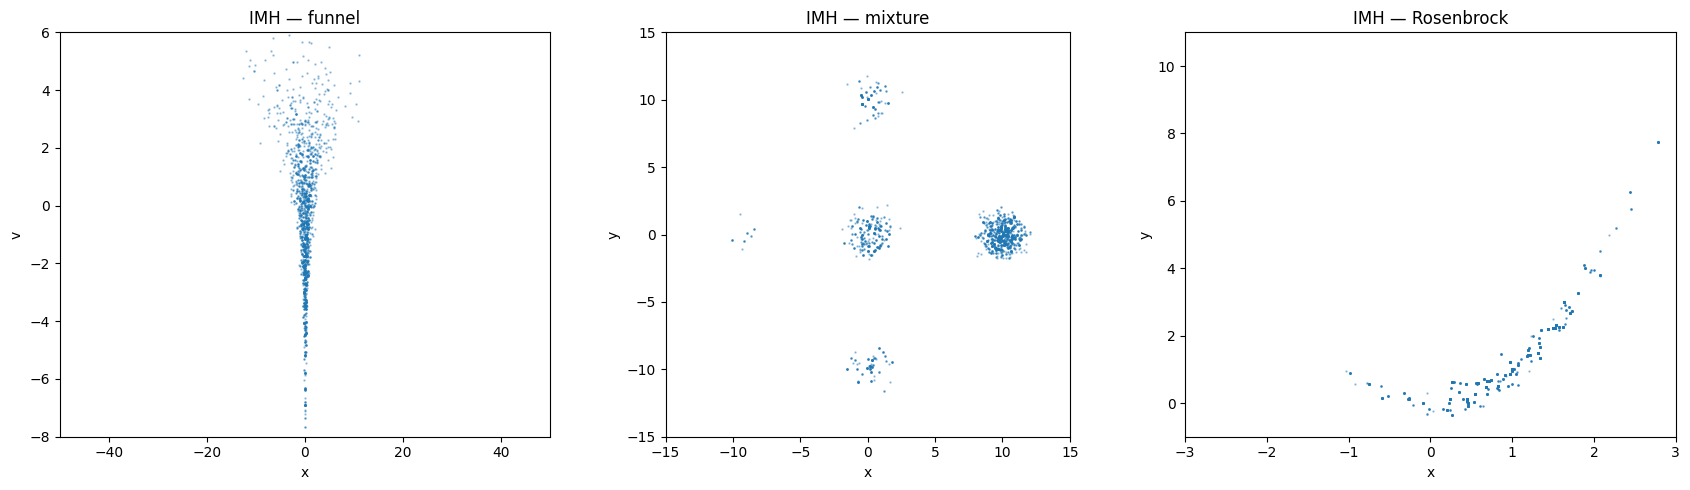

In [11]:
s_f = run_mcmc(gaussian_imh(funnel_logdensity), init_funnel, key, num_samples=2_000, thin=10, init_params_kwargs={"cov": 50.0 * jnp.ones(2)})
s_m = run_mcmc(gaussian_imh(mixture_logdensity), init_mixture, key, num_samples=2_000, thin=10, init_params_kwargs={"cov": 50.0 * jnp.ones(2)})
s_b = run_mcmc(gaussian_imh(rosenbrock_logdensity), init_rosenbrock, key, num_samples=2_000, thin=10, init_params_kwargs={"cov": 50.0 * jnp.ones(2)})
plot_triplet("IMH", s_f, s_m, s_b)

## Elliptical Slice Sampling

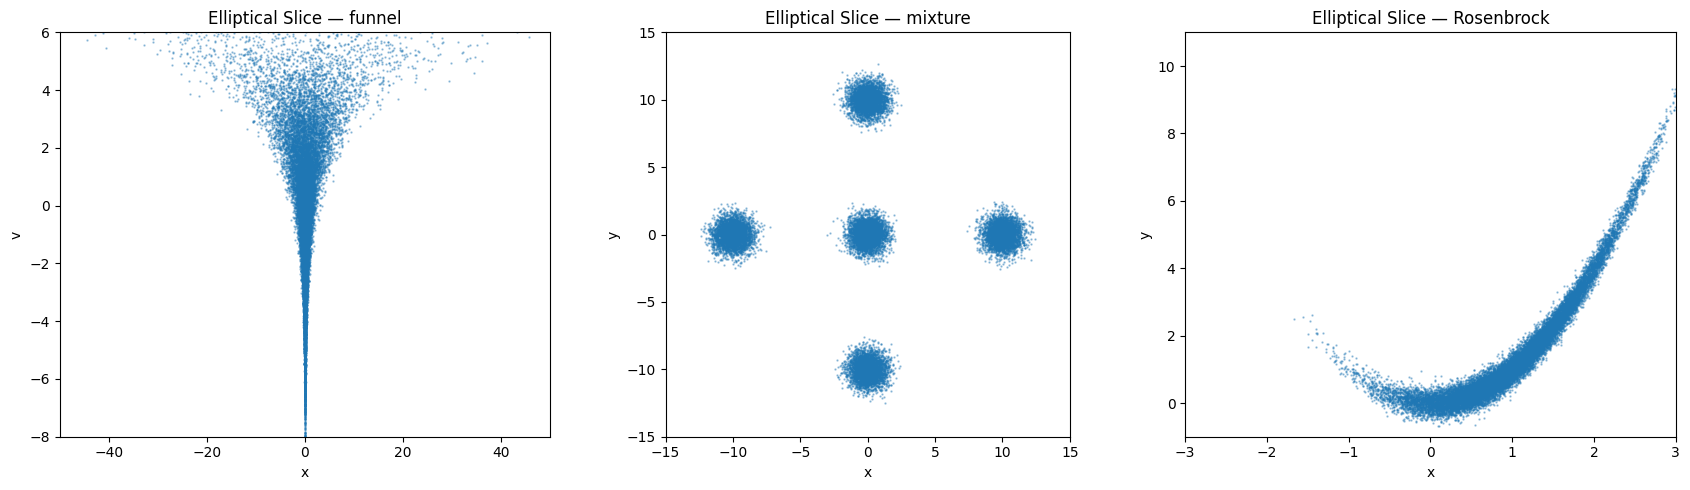

In [12]:
s_f = run_mcmc(elliptical_slice(funnel_logdensity, cov_matrix=50.0 * jnp.ones(2), mean=jnp.zeros(2)), init_funnel, key, thin=10)
s_m = run_mcmc(elliptical_slice(mixture_logdensity, cov_matrix=50.0 * jnp.ones(2), mean=jnp.zeros(2)), init_mixture, key, thin=10)
s_b = run_mcmc(elliptical_slice(rosenbrock_logdensity, cov_matrix=50.0 * jnp.ones(2), mean=jnp.zeros(2)), init_rosenbrock, key, thin=10)
plot_triplet("Elliptical Slice", s_f, s_m, s_b)

## Slice Sampling

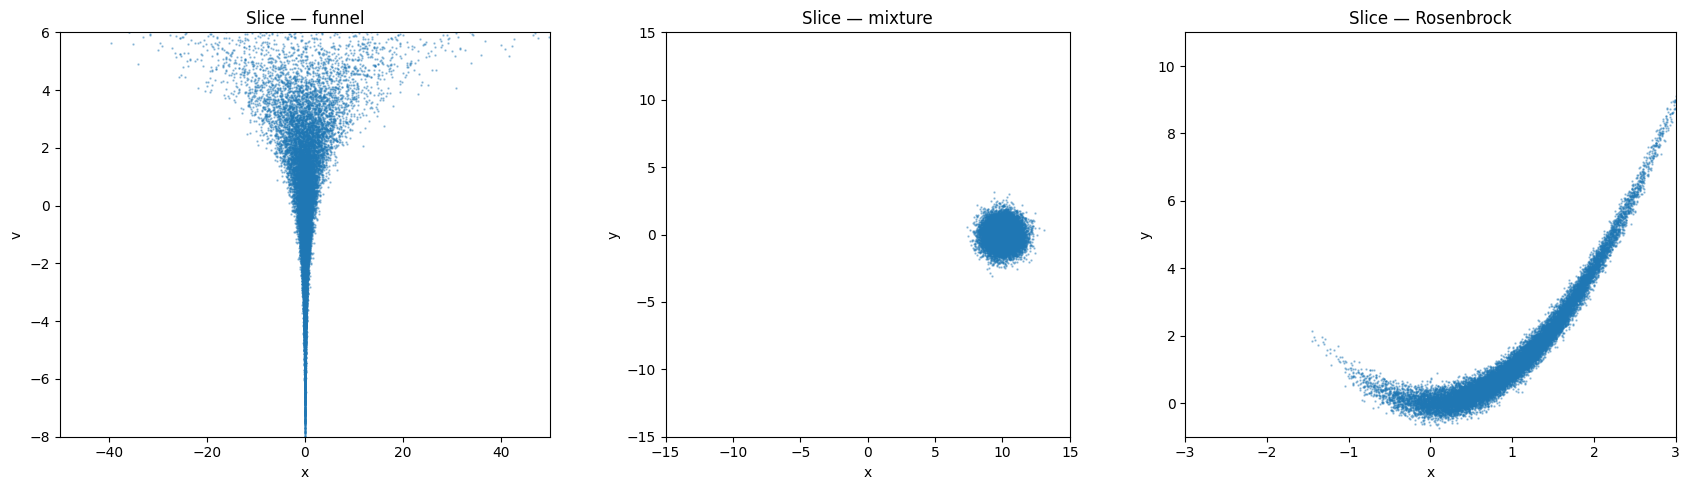

In [13]:
s_f = run_mcmc(slice(funnel_logdensity, step_size=1.0), init_funnel, key)
s_m = run_mcmc(slice(mixture_logdensity, step_size=1.0), init_mixture, key)
s_b = run_mcmc(slice(rosenbrock_logdensity, step_size=0.1), init_rosenbrock, key)
plot_triplet("Slice", s_f, s_m, s_b)

## Latent Slice Sampling

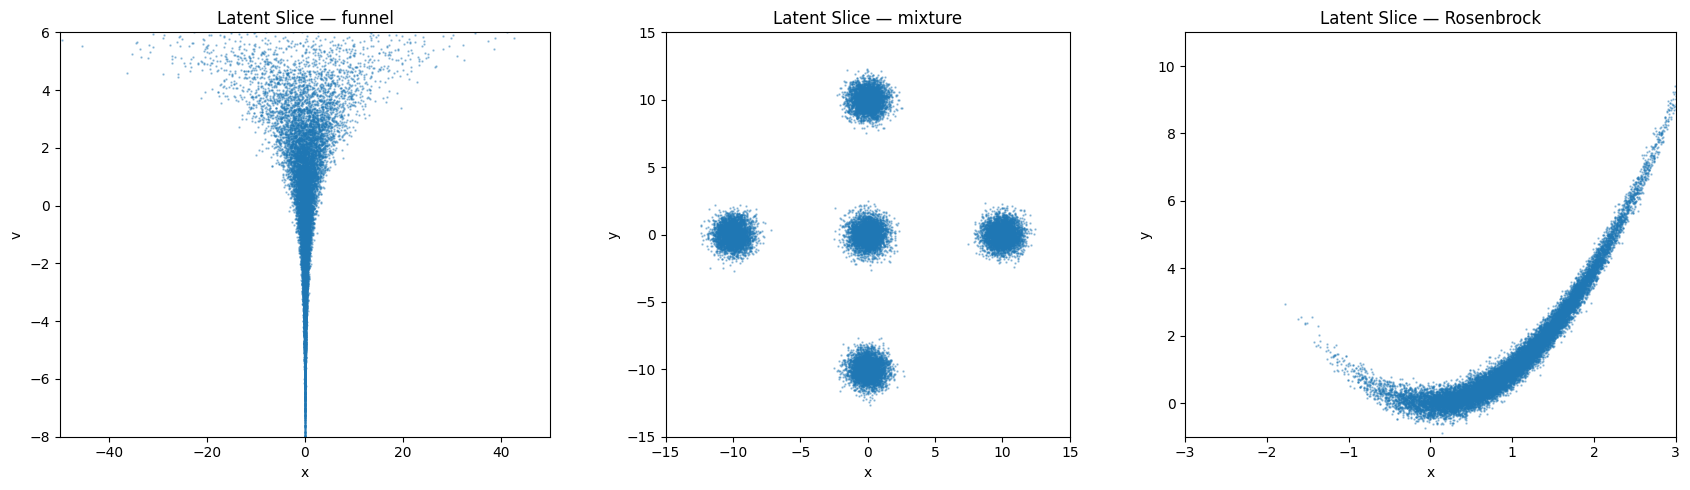

In [14]:
s_f = run_mcmc(latent_slice(funnel_logdensity), init_funnel, key, init_params_kwargs={"step_size": 0.1})
s_m = run_mcmc(latent_slice(mixture_logdensity), init_mixture, key, init_params_kwargs={"step_size": 0.1})
s_b = run_mcmc(latent_slice(rosenbrock_logdensity), init_rosenbrock, key, init_params_kwargs={"step_size": 0.1})
plot_triplet("Latent Slice", s_f, s_m, s_b)

## MCLMC

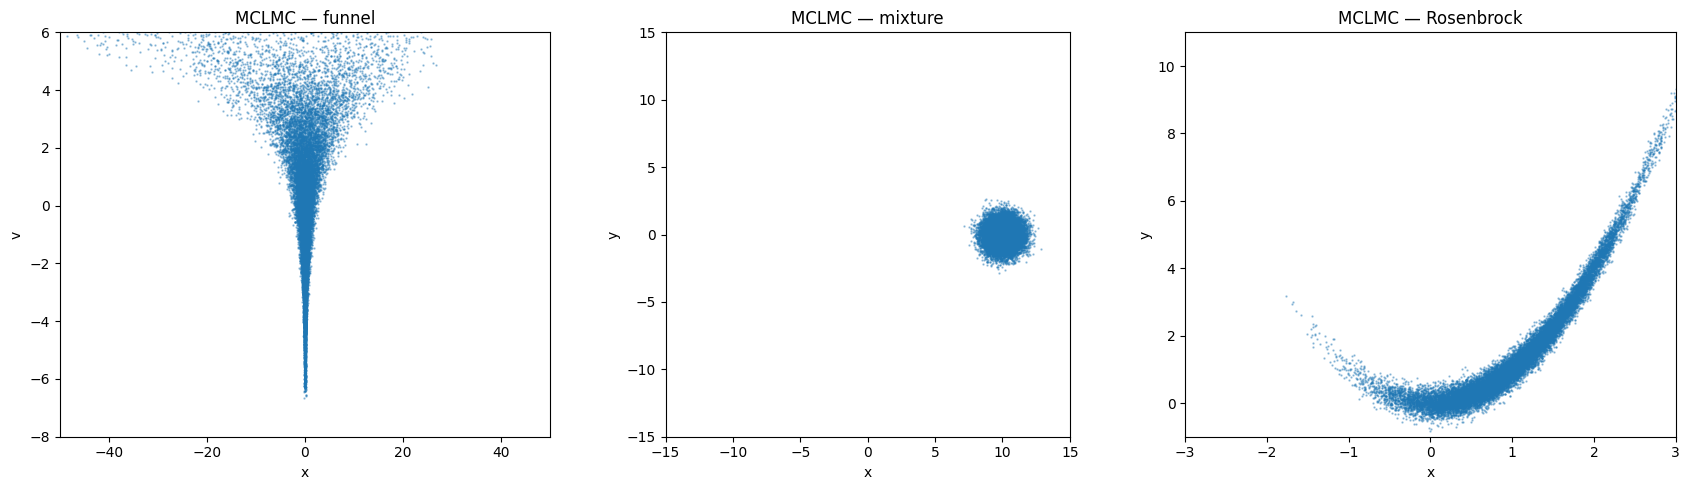

In [15]:
s_f = run_mcmc(mclmc(funnel_logdensity), init_funnel, key, init_params_kwargs={"step_size": 0.1, "L": 1.0})
s_m = run_mcmc(mclmc(mixture_logdensity), init_mixture, key, init_params_kwargs={"step_size": 0.1, "L": 1.0})
s_b = run_mcmc(mclmc(rosenbrock_logdensity), init_rosenbrock, key, init_params_kwargs={"step_size": 0.05, "L": 1.0})
plot_triplet("MCLMC", s_f, s_m, s_b)

## Adjusted MCLMC

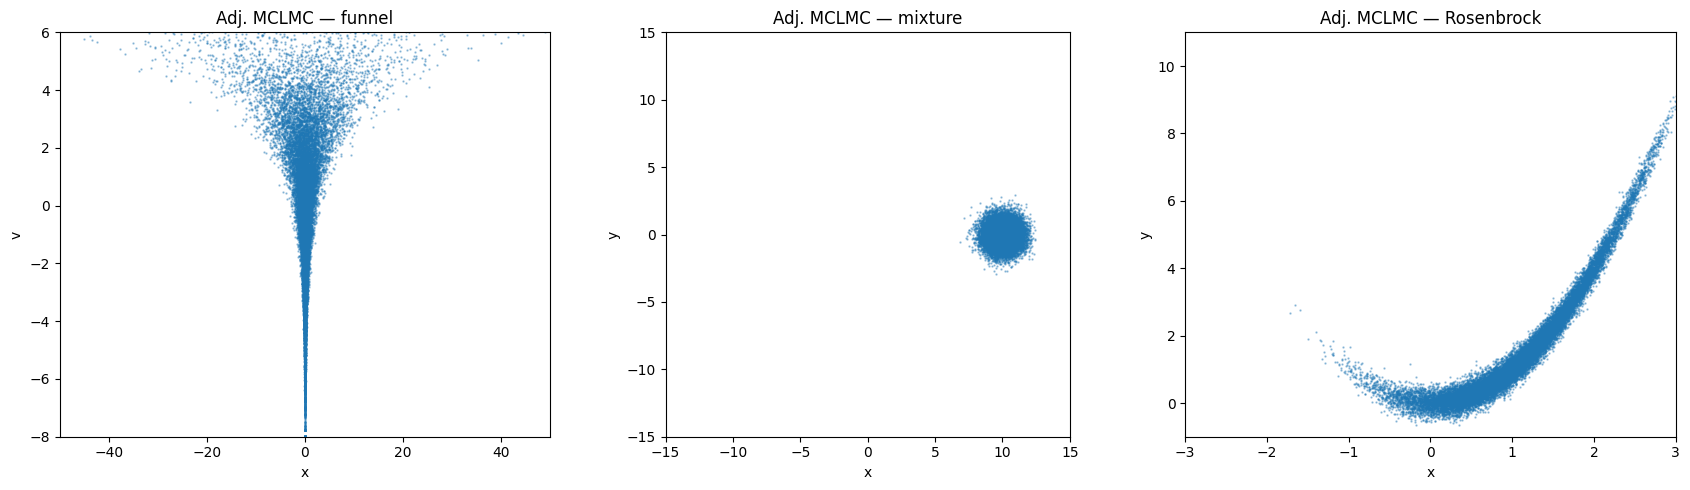

In [16]:
s_f = run_mcmc(adjusted_mclmc(funnel_logdensity), init_funnel, key, init_params_kwargs={"step_size": 0.05, "num_integration_steps": 50})
s_m = run_mcmc(adjusted_mclmc(mixture_logdensity), init_mixture, key, init_params_kwargs={"step_size": 0.05, "num_integration_steps": 50})
s_b = run_mcmc(adjusted_mclmc(rosenbrock_logdensity), init_rosenbrock, key, init_params_kwargs={"step_size": 0.005, "num_integration_steps": 50})
plot_triplet("Adj. MCLMC", s_f, s_m, s_b)

## Adjusted MCLMC (Dynamic)

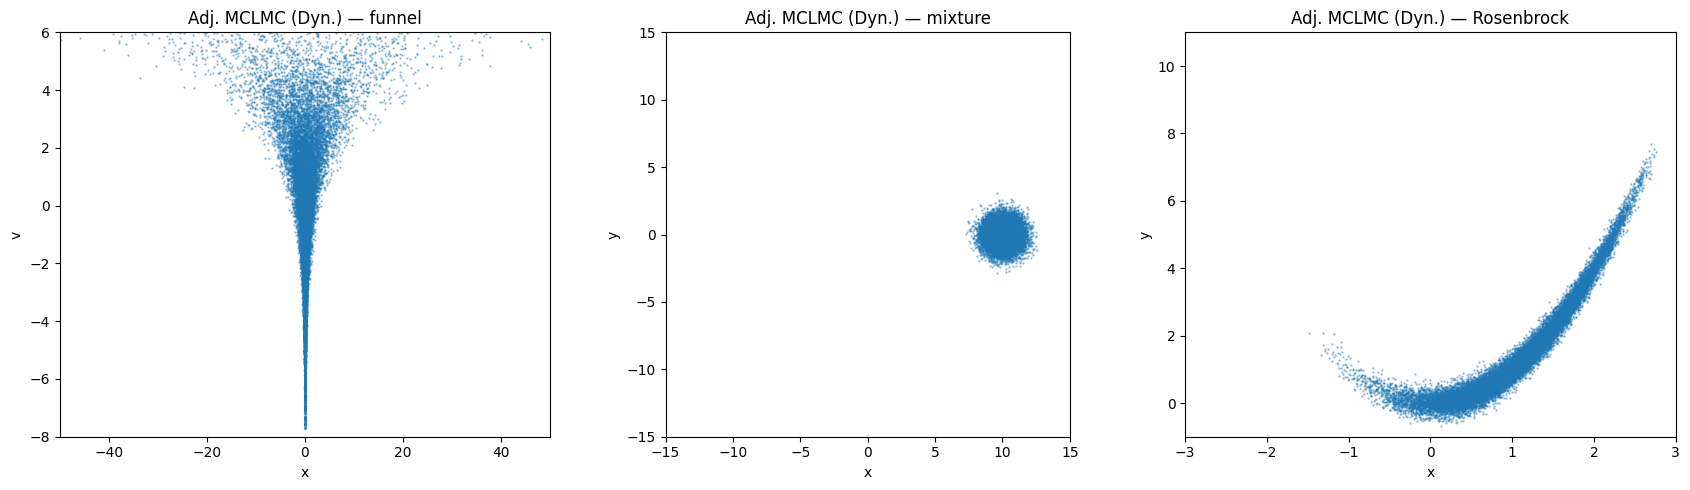

In [17]:
s_f = run_mcmc(adjusted_mclmc_dynamic(funnel_logdensity, average_integration_steps=30), init_funnel, key, init_params_kwargs={"step_size": 0.05})
s_m = run_mcmc(adjusted_mclmc_dynamic(mixture_logdensity, average_integration_steps=30), init_mixture, key, init_params_kwargs={"step_size": 0.05})
s_b = run_mcmc(adjusted_mclmc_dynamic(rosenbrock_logdensity, average_integration_steps=30), init_rosenbrock, key, init_params_kwargs={"step_size": 0.005})
plot_triplet("Adj. MCLMC (Dyn.)", s_f, s_m, s_b)

## Kernel tuning (fit_params)

Many kernels expose `fit_params`, which runs a short adaptation loop to tune
step size and (for HMC/NUTS) the inverse mass matrix.  This is especially
useful when you don't know good defaults ahead of time.

In [18]:
def run_mcmc_tuned(kernel, init_z, key, num_adapt=500, num_samples=20_000, thin=10):
    """Run fit_params then sample."""
    state = kernel.init(init_z, rng_key=key)
    init_p = kernel.init_params(state)
    state, tuned_params = kernel.fit_params(key, state, init_p, num_steps=num_adapt)
    samples, final_state = MCMC(kernel).sample(key, state, num_samples, params=tuned_params, thin=thin)
    return samples, final_state, tuned_params

### HMC with window adaptation

Window adaptation tunes `step_size` and the diagonal `inverse_mass_matrix`
so that the sampler automatically accounts for the scale of each dimension.

In [19]:
kernel_hmc = hmc(funnel_logdensity, num_integration_steps=50)
s_f, st_f, p_f = run_mcmc_tuned(kernel_hmc, init_funnel, key)
print(f"Funnel — step_size: {p_f.step_size:.4f}, mass diag: {p_f.inverse_mass_matrix}")

kernel_hmc = hmc(mixture_logdensity, num_integration_steps=50)
s_m, st_m, p_m = run_mcmc_tuned(kernel_hmc, init_mixture, key)
print(f"Mixture — step_size: {p_m.step_size:.4f}, mass diag: {p_m.inverse_mass_matrix}")

kernel_hmc = hmc(rosenbrock_logdensity, num_integration_steps=50)
s_b, st_b, p_b = run_mcmc_tuned(kernel_hmc, init_rosenbrock, key)
print(f"Rosenbrock — step_size: {p_b.step_size:.4f}, mass diag: {p_b.inverse_mass_matrix}")

Funnel — step_size: 0.0723, mass diag: [3.4559412 7.8839793]
Mixture — step_size: 0.8959, mass diag: [0.28825364 0.4646043 ]
Rosenbrock — step_size: 0.0772, mass diag: [0.3655799 2.1520889]


In [20]:
mcmc = MCMC(kernel_hmc, verbose=True)
_ = mcmc.run(jax.random.key(0), st_b, 1000000, params=p_b)

Progress: |██████████████████████████████████████████████████| 100.00% logdensity: -0.89 acceptance_rate: 0.97

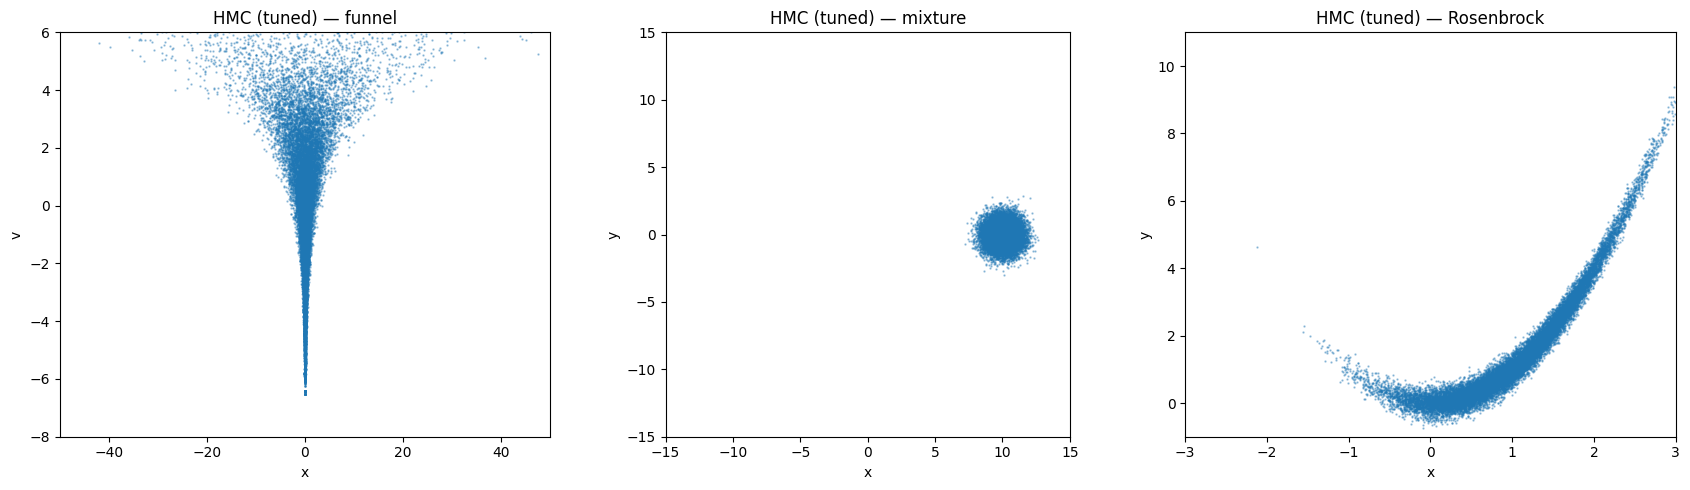

In [21]:
plot_triplet("HMC (tuned)", s_f, s_m, s_b)

### MALA with step-size adaptation

MALA adaptation tunes `step_size` toward a target acceptance rate
(default 0.65).  Compare against the hand-tuned MALA above.

In [22]:
kernel_mala = mala(funnel_logdensity)
s_f, st_f, p_f = run_mcmc_tuned(kernel_mala, init_funnel, key)
print(f"Funnel — step_size: {p_f.step_size:.4f}")

kernel_mala = mala(mixture_logdensity)
s_m, st_m, p_m = run_mcmc_tuned(kernel_mala, init_mixture, key)
print(f"Mixture — step_size: {p_m.step_size:.4f}")

kernel_mala = mala(rosenbrock_logdensity)
s_b, st_b, p_b = run_mcmc_tuned(kernel_mala, init_rosenbrock, key)
print(f"Rosenbrock — step_size: {p_b.step_size:.4f}")

Funnel — step_size: 0.3941
Mixture — step_size: 0.4859
Rosenbrock — step_size: 0.0056


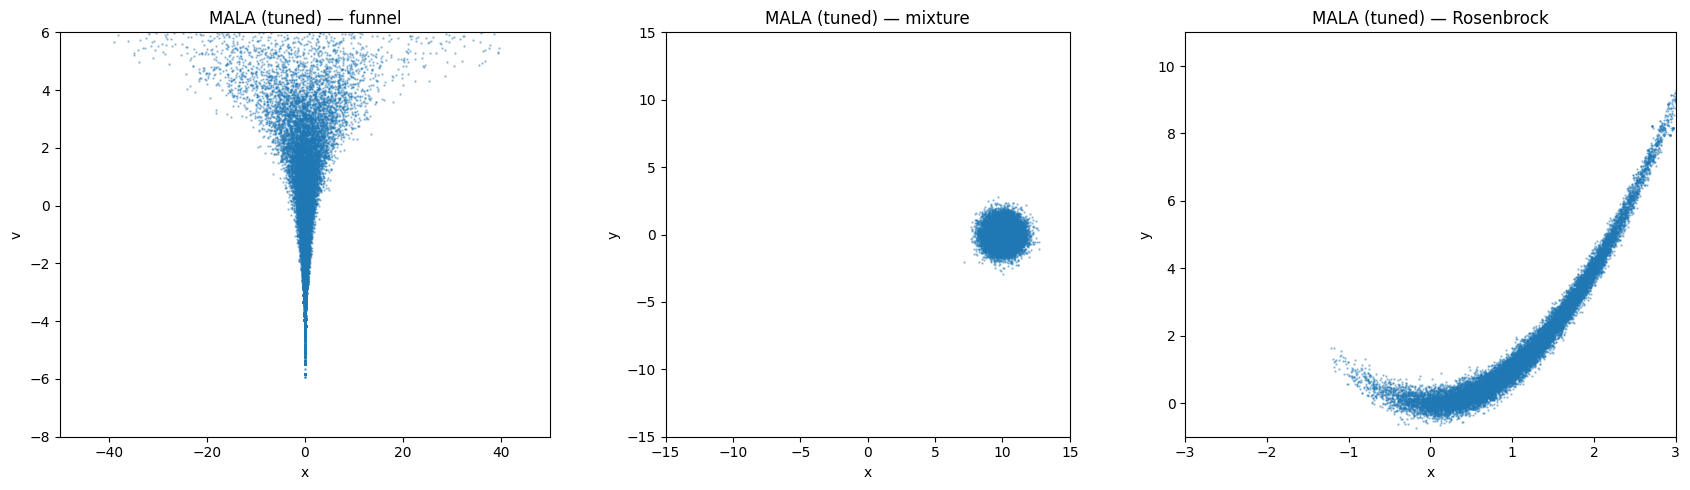

In [23]:

plot_triplet("MALA (tuned)", s_f, s_m, s_b)

### NUTS with window adaptation

In [24]:
kernel_nuts = nuts(funnel_logdensity, max_num_doublings=10)
s_f, st_f, p_f = run_mcmc_tuned(kernel_nuts, init_funnel, key)
print(f"Funnel — step_size: {p_f.step_size:.4f}, mass diag: {p_f.inverse_mass_matrix}")

kernel_nuts = nuts(mixture_logdensity, max_num_doublings=10)
s_m, st_m, p_m = run_mcmc_tuned(kernel_nuts, init_mixture, key)
print(f"Mixture — step_size: {p_m.step_size:.4f}, mass diag: {p_m.inverse_mass_matrix}")

kernel_nuts = nuts(rosenbrock_logdensity, max_num_doublings=10)
s_b, st_b, p_b = run_mcmc_tuned(kernel_nuts, init_rosenbrock, key)
print(f"Rosenbrock — step_size: {p_b.step_size:.4f}, mass diag: {p_b.inverse_mass_matrix}")

Funnel — step_size: 0.1396, mass diag: [12.746476   7.7220244]
Mixture — step_size: 1.0447, mass diag: [0.40849406 0.38236544]
Rosenbrock — step_size: 0.1617, mass diag: [0.32702845 0.7825236 ]


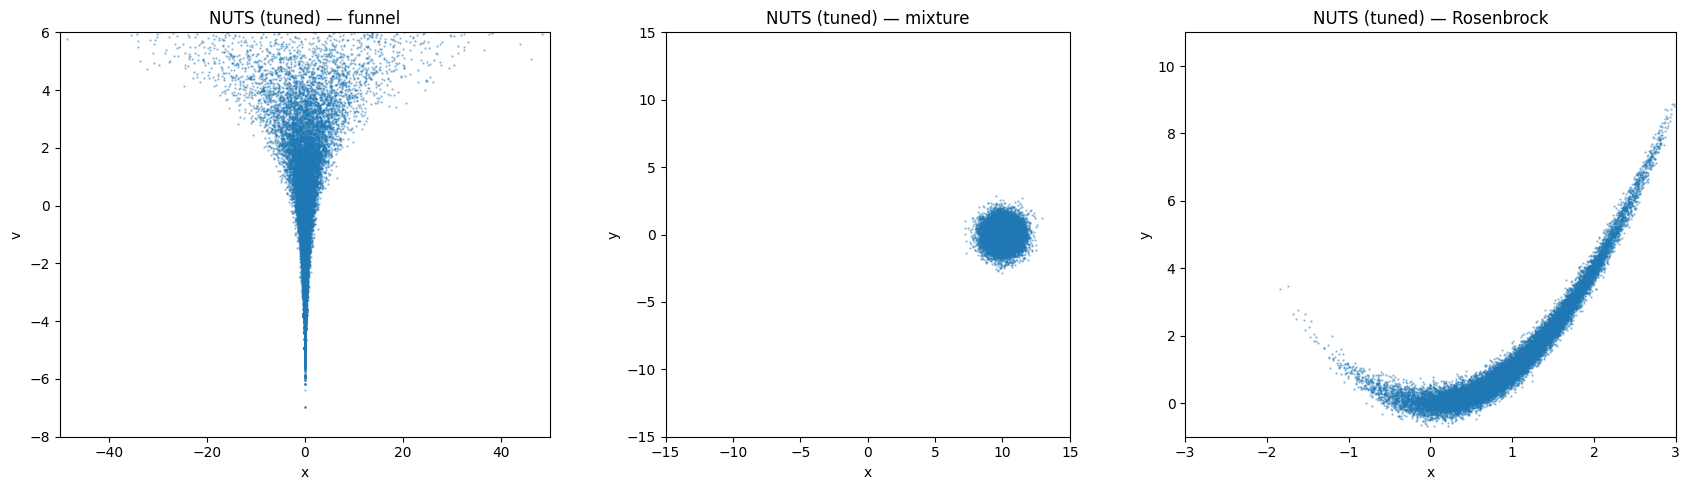

In [25]:
plot_triplet("NUTS (tuned)", s_f, s_m, s_b)

## Observations

**Funnel (varying curvature):** HMC/NUTS explore the full funnel. MALA mixes slowly on the narrow neck. RW-MH is very slow. Slice-based methods (IMH, ESS, Slice) depend on proposal/direction quality.

**Mixture (disconnected modes):** Local methods get trapped in a single mode. IMH, ESS, and Slice can occasionally hop between modes with a wide proposal, but acceptance is low.

**Rosenbrock (thin curved ridge):** Gradient methods (HMC, NUTS, MALA) handle the ridge geometry well with small step sizes. RW-MH struggles to follow the curve. Slice sampling can adapt along the ridge if directions are chosen well.

**Tuning:** `fit_params` removes the need to hand-pick `step_size` and `inverse_mass_matrix`.  Window adaptation (HMC/NUTS) finds a good mass matrix that rescales each dimension, which is particularly helpful on the Rosenbrock target where x and y have very different scales.